In [5]:
from typing import List, Tuple, Union, Dict, Optional, Callable
import torch
from torch import Tensor
import numpy as np
from numpy import ndarray
from sympy import symbols, cos, sin, tan, Matrix, init_printing
import scipy
from math import sqrt
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm
from time import time
# For creating 3D animation clips
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from IPython.display import HTML
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.gridspec import GridSpec
matplotlib.rcParams['animation.embed_limit'] = 22 * 1000  # in MB, our embedded limit for creating the 3D
plt.rcParams['text.usetex'] = True

In [6]:
to_numpy = lambda x : x.detach().numpy() if isinstance(x, Tensor) else x
set_t = {
    "dtype": torch.float32,
    "device": torch.device("cpu"),  # set to cpu if you don't have a graphics card
}
init_printing()


# Quadrotor 12 State Dynamic Linearization
One popular manner of stabilizing a nonlinear system is to linearize it about some equilibrium point and use LQR to produce a linear state-feedback controller that stabilizes the system to this equilibrium point. For a linear time-invariant (LTI) where the goal is to stabilize the system with an infinite time-horizon, the LQR problem has an exact solution given by the algebraic Ricatti equation (ARE).

Below, we symbolically define the parameters of our system. In the paper, we are only given the equations on how to update our system's positional and angular acceleration. However, if we want our system to be linearized in the form:
$$
\dot{x} = Ax + Bu
$$

The non-linear dynamics of our system are described as:
$$
\dot{x} = f(x) = \begin{bmatrix}v_x \\ v_y \\ v_z \\ a_x \\ a_y \\ a_z \\ p \\ q \\ r \\ \dot{p} \\ \dot{q} \\ \dot{r} \end{bmatrix} =
\begin{bmatrix}
v_x \\ v_y \\ v_z \\
\frac{1}{m}\begin{bmatrix}0\\0\\-mg\end{bmatrix} + \frac{1}{m}R\begin{bmatrix}0\\0\\\sum_{i=1}^4 F_i\end{bmatrix} \\
p \\ q\\ r \\
I^{-1}\left( \begin{bmatrix} L(F_2 - F_4) \\ L(F_3 - F_1) \\ M_1 - M_2 + M_3 - M_4 \end{bmatrix} - \begin{bmatrix}p\\q\\r\end{bmatrix}\times I\begin{bmatrix}p\\q\\r\end{bmatrix} \right)
\end{bmatrix}
$$
where
$$
\textit{ (state vector) }x := \begin{bmatrix}p_x & p_y & p_z & v_x & v_y & v_z & \phi & \theta & \psi & p & q & r \end{bmatrix}^\top
$$
$$
\textit{ (Inertia matrix) } I := \begin{bmatrix} I_x & 0 & 0 \\ 0 & I_y & 0 \\ 0 & 0 & I_z\end{bmatrix}
$$
$$
\textit{  (mass) } m
$$
$$
\textit{  (gravity) } g
$$
$$
\textit{  (length of arm from body to propeller) } L
$$
$$
\textit{ (force of each propeller) } F_i := k_f u_i^2
$$
$$
\textit{ (moment of each properller) } M_i := k_m u_i^2
$$
$$
\textit{ (position along each direction) } \begin{bmatrix}p_x & p_y & p_z\end{bmatrix}
$$
$$
\textit{ (velocity along each direction) } \begin{bmatrix}v_x & v_y & v_z\end{bmatrix}
$$
$$
\textit{ (acceleration along each direction) } \begin{bmatrix}a_x & a_y & a_z\end{bmatrix}
$$
$$
\textit{ (roll, pitch, and yaw) } \begin{bmatrix}\phi & \theta & \psi \end{bmatrix}
$$
$$
\textit{ (angular velocity) } \begin{bmatrix}p & q & r \end{bmatrix}
$$
$$
\textit{ (angular acceleration) } \begin{bmatrix}\dot{p} & \dot{q} & \dot{r} \end{bmatrix}
$$
$$
\textit{ (rotation matrix from body frame to world frame) } R
$$
Since we are using SymPy, and this module does not have a cross product operator, it is convenient to know that the following equivalance holds: $x\times y = \mathcal{S}(x)y$, where $\mathcal{S}$ is the skew matrix operator. In other words, we can replace the term:
$$
\begin{bmatrix}p\\q\\r\end{bmatrix}\times I\begin{bmatrix}p\\q\\r\end{bmatrix}
$$
with
$$
\begin{bmatrix}0&p&q\\-p&0&r\\-q&-r&0\end{bmatrix}I\begin{bmatrix}p\\q\\r\end{bmatrix}
$$
We want to linearize these dynamics such that it is in the form:
$$
\begin{bmatrix}v_x \\ v_y \\ v_z \\ a_x \\ a_y \\ a_z \\ p \\ q \\ r \\ \dot{p} \\ \dot{q} \\ \dot{r} \end{bmatrix} = A\begin{bmatrix}p_x\\p_y\\p_z\\v_x \\ v_y \\ v_z\\\phi\\\theta\\\psi \\ p \\ q \\ r \end{bmatrix} + Bu
$$
In shorthand, this is:
$$
\dot{x} = Ax + Bu
$$
This is the form that we want. In order to get $A$, we need to linearize the dynamics w.r.t. the state variables by getting the Jacobian of $\frac{\partial}{\partial x}f(x)$. Likewise, we get $B$ by linearizing the dynamics w.r.t. the control input by getting the Jacobian of $\frac{\partial}{\partial u}f(x)$.

In [7]:
# Define parameters, state variables and control input
m, g, km, kf = symbols('m g km kf')  # Position, velocity, control
phi, theta, psi = symbols('phi theta psi')
L = symbols('L')
p, q, r = symbols('p q r')
F1, F2, F3, F4 = symbols('F1 F2 F3 F4')
F = Matrix([F1, F2, F3, F4])
I1, I2, I3 = symbols('I1 I2 I3')
I = Matrix([[I1, 0, 0], [0, I2, 0], [0, 0, I3]])
I_inv = I.inv()
px, py, pz, vx, vy, vz, ax, ay, az = symbols('px py pz vx vy vz ax ay az')
u1, u2, u3, u4 = symbols('u1 u2 u3 u4')
u = Matrix([u1, u2, u3, u4])
F1 = u1**2 *kf
F2 = u2**2 *kf
F3 = u3**2 *kf
F4 = u4**2 *kf
M1 = u1**2 *km
M2 = u2**2 *km
M3 = u3**2 *km
M4 = u4**2 *km

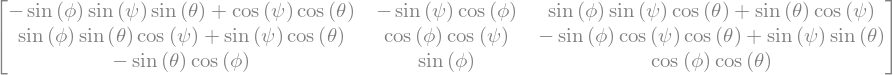

In [8]:
# the rotation matrix from the quadrotor's body frame to the world frame
R = Matrix([[cos(psi)*cos(theta) - sin(phi)*sin(psi)*sin(theta), -cos(phi)*sin(psi), cos(psi)*sin(theta) + cos(theta)*sin(phi)*sin(psi)],
                 [cos(theta)*sin(psi) + cos(psi)*sin(phi)*sin(theta), cos(phi)*cos(psi), sin(psi)*sin(theta) - cos(psi)*cos(theta)*sin(phi)],
                 [-cos(phi)*sin(theta), sin(phi), cos(phi)*cos(theta)]])
R

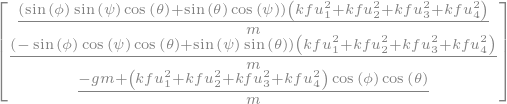

In [9]:
# the equations describing our positional acceleration
acc_matrix = (1/m) * ((Matrix([0, 0, -m*g]) + R@Matrix([0, 0, F1 + F2 + F3 + F4])))
acc_matrix

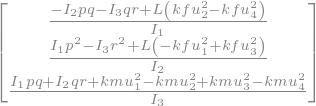

In [10]:
# the equations describing our angular acceleration
ang_matrix = I_inv @ (Matrix([[L*(F2-F4)], [L*(F3-F1)], [M1 - M2 + M3 - M4]]) - (Matrix([[0, p, q], [-p , 0, r], [-q, -r, 0]])@(I@Matrix([p, q, r]))))
ang_matrix

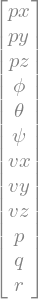

In [11]:
# the state vector
# x = Matrix([px, py, pz, vx, vy, vz, phi, theta, psi, p, q, r])
x = Matrix([px, py, pz, phi, theta, psi, vx, vy, vz, p, q, r])
x

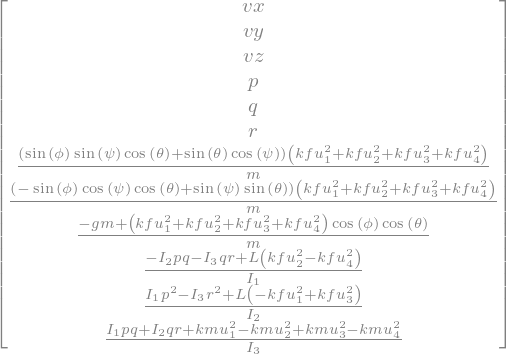

In [12]:
# derivative of the state vector ( same as nonlinear dynamics f(x) )
# xdot = Matrix([vx, vy, vz, *acc_matrix[:, 0], p, q, r, *ang_matrix[:, 0]])
xdot = Matrix([vx, vy, vz, p, q, r, *acc_matrix[:, 0], *ang_matrix[:, 0]])
xdot

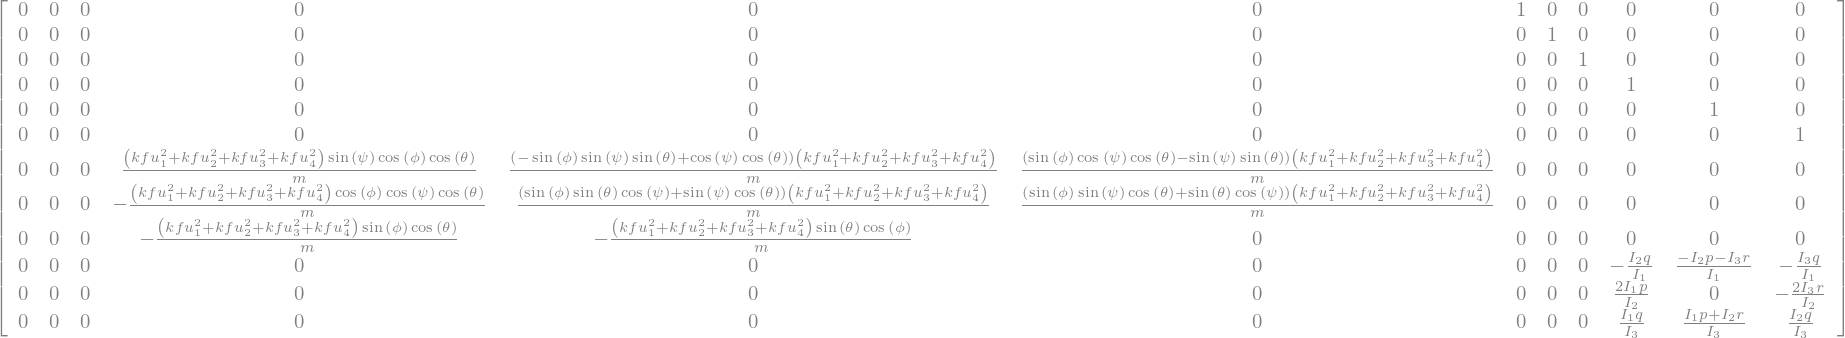

In [13]:
# linearize the dynamics w.r.t. x to get A
A_sym = xdot.jacobian(x)
A_sym

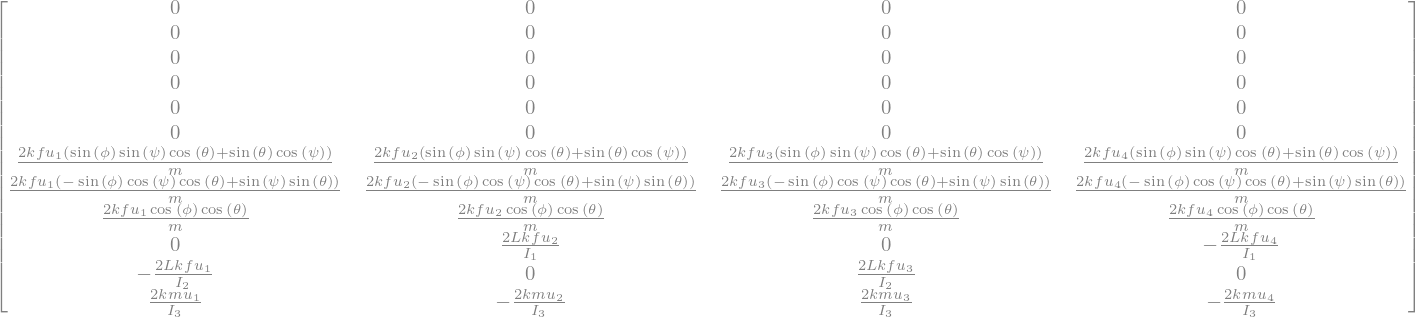

In [14]:
# lilnearize the dynamics w.r.t. xdot to get B
B_sym = xdot.jacobian(u)
B_sym

In [15]:
# Here we substitute in our symbolic values with our actual model parameters
values: Dict[symbols, float] = {
    L: 0.0397,
    I1: 2.3951e-5,
    I2: 2.3951e-5,
    I3: 3.2347e-5,
    px: 10., py: 10., pz: 10.,
    vx: 0, vy: 0, vz: 0,
    p: 0., q: 0., r: 0.,
    phi: 0.0, theta: 0.0, psi: 0.0,
    g: 9.81,
    km: 7.94e-12,
    kf: 3.16e-10,
    F1: u1**2 *kf,
    F2: u2**2 *kf,
    F3: u3**2 *kf,
    F4: u4**2 *kf,
    m: 0.027
}
ss_u = sqrt((values[m]*values[g])/(4*values[kf]))
values[u1] = ss_u
values[u2] = ss_u
values[u3] = ss_u
values[u4] = ss_u

# Substitute values into the matrix
A_numeric = A_sym.subs(values)
B_numeric = B_sym.subs(values)
print(f"Control Equilibrium: {ss_u}")

Control Equilibrium: 14475.809152959684


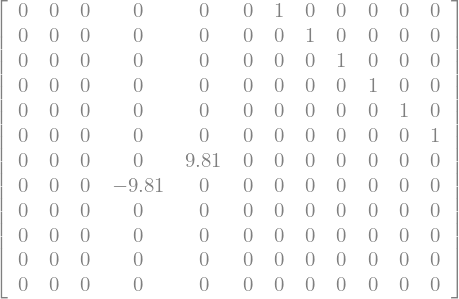

In [16]:
A_numeric

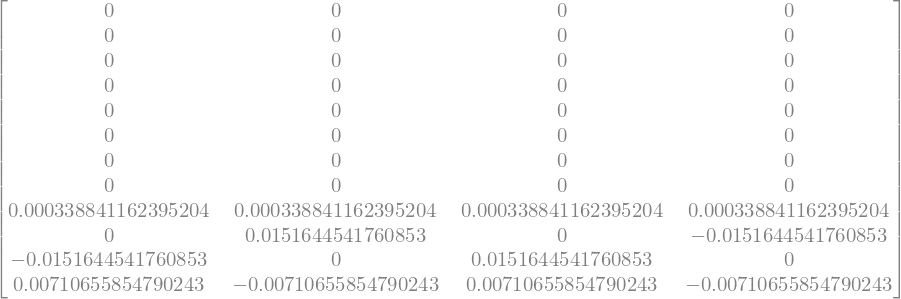

In [17]:
B_numeric

In [18]:
# Convert to a NumPy array
A_numpy = np.array(A_numeric.evalf(), dtype=np.float32)
B_numpy = np.array(B_numeric.evalf(), dtype=np.float32)

In [19]:
A_numpy

array([[ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  1.  ,  0.  ,  0.  ,
         0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  1.  ,  0.  ,
         0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  1.  ,
         0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         1.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ,  1.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ,  0.  ,  1.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  9.81,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  , -9.81,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ,  0.  ,  0.  ],
       [ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
         0.  ,  0.  

In [20]:
B_numpy

array([[ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.00033884,  0.00033884,  0.00033884,  0.00033884],
       [ 0.        ,  0.01516445,  0.        , -0.01516445],
       [-0.01516445,  0.        ,  0.01516445,  0.        ],
       [ 0.00710656, -0.00710656,  0.00710656, -0.00710656]],
      dtype=float32)

In [21]:
def get_controllability_matrix(a: ndarray, b: ndarray) -> ndarray:
    """
    For an LTI system, return its controllability matrix.
    :param a: Linear state equations w.r.t. current state.
    :param b: Linear state equations w.r.t. input.
    :return:
    """
    n = a.shape[1]  # state dimension
    m = b.shape[1]  # control dimension

    # Use Cayley-Hamilton theorem to create a (n, nxm) controllability matrix whose rank tells us
    # how many states in the system are controllable.
    ctrl_matrix = b
    for i in range(1, n):
        ctrl_matrix = np.hstack((ctrl_matrix, np.linalg.matrix_power(a, i)@b))
    assert ctrl_matrix.shape == (n, n*m), f"Controllability matrix does not have the proper shape of ({(n, n*m)})"
    return ctrl_matrix

def controllability_rank(c: ndarray) -> int:
    """
    Gets the rank of the controllability matrix which tells us how many states in the system are controllable.
    :param c:   Controllability matrix
    :return:    Rank
    """
    rank_c = np.linalg.matrix_rank(c)
    return rank_c

def transform_system(A, B, T):

    A_transformed = T@A@T.inv()
    B_transformed = T@B

    return A_transformed, B_transformed

def get_controllable_subsystem(a: ndarray, b: ndarray, c: ndarray, rank_c: int) -> Tuple[ndarray, ndarray, ndarray]:
    """
    Performs Kalman decomposition to get the controllable subsystem as well as the linear transformation matrix T which puts the original system into this modal form.
    :param a:       Linear state dynamics w.r.t. current state.
    :param b:       Linear state dynamics w.r.t. input.
    :param c:       Controllability matrix.
    :param rank_c:  Rank of the controllability matrix.
    :return:
    """

    # Use QR decomposition to find an orthonormal basis for the controllable subspace
    Q, _ = np.linalg.qr(c)  # Q has orthonormal columns spanning the controllable subspace
    T = Q  # Transformation matrix

    # Transform A and B
    A_transformed = np.linalg.inv(T) @ a @ T
    B_transformed = np.linalg.inv(T) @ b
    print(f"New state system: ")
    print(f"Transformed A: \n{A_transformed}")
    print(f"Transformed B: \n{B_transformed}")
    # Identify which states are controllable
    controllable_states = np.where(np.sum(np.abs(T), axis=1) > 1e-6)[0]
    uncontrollable_states = np.setdiff1d(np.arange(A.shape[0]), controllable_states)
    print(f"Controllable states: {controllable_states}")
    print(f"Uncontrollable states: {uncontrollable_states}")

    # Extract controllable part
    A_c = A_transformed[:rank_c, :rank_c]
    B_c = B_transformed[:rank_c, :]

    return A_c, B_c, T

In [22]:
ctrl_matrix = get_controllability_matrix(A_numpy, B_numpy)
ctrl_rank = controllability_rank(ctrl_matrix)
can_ctrl = ctrl_rank >= A_numpy.shape[1]
print(f"Is this linear system controllable? {can_ctrl}")
print(f"Controllability matrix has a rank of {ctrl_rank} for a system with {A_numpy.shape[1]} state dimensions.")

# TODO: We don't need to perform the Kalman decomposition as we can now see that the system is controllable.
# # get the controllable subsystem:
# A_c, B_c, T = get_controllable_subsystem(A_numpy, B_numpy, ctrl_matrix, ctrl_rank)

Is this linear system controllable? True
Controllability matrix has a rank of 12 for a system with 12 state dimensions.


At this point, we have the equations that we need in order to produce a linear state-feedback controller for our controllable subsystem in the form:
$$
u = -Kx
$$
Finding this controller involves solving the LQR (Linear Quadratic Regular) control optimal problem:
$$
\min_u J(x, u) := \min_u \int_{t=0}^{\infty} x^\top Qx + u^\top R u \; dt
$$
where $Q \in \mathbb{R}^{n\times n}$ and $R \in \mathbb{R}^{m\times m}$. We also have that $Q$ and $R$ are both symmetric. $Q$ is positive semi-definite and $R$ is positive definite.

Luckily, this optimization problem has a closed-form solution given by the algebraic Riccati equation, and scipy has a method that can solve for this solution.

In [23]:
Q_weights = np.ones(A_numpy.shape[1])
R_weights = np.ones(B_numpy.shape[1])

# we can update specific weights depending on which states/controls we care about more

Q = np.diag(Q_weights)
R = np.diag(R_weights)
S = scipy.linalg.solve_continuous_are(A_numpy, B_numpy, Q, R)
K = np.linalg.solve(R, B_numpy.T @ S)
print(f"K (shape : {K.shape})\n{K}")

K (shape : (4, 12))
[[-7.07106781e-01 -1.69566287e-16  5.00000000e-01  9.00091045e-15
  -5.39415035e+01  5.00000000e-01 -2.87684351e+00 -5.86385767e-16
   2.71672377e+01  6.32865340e-15 -5.96456326e+01  5.95220734e+00]
 [-4.85387485e-17 -7.07106781e-01  5.00000000e-01  5.39415035e+01
  -2.54285853e-15 -5.00000000e-01 -1.98112634e-16 -2.87684351e+00
   2.71672377e+01  5.96456326e+01 -1.73353979e-15 -5.95220734e+00]
 [ 7.07106781e-01 -9.40895896e-17  5.00000000e-01  3.76353222e-15
   5.39415035e+01  5.00000000e-01  2.87684351e+00 -2.45023215e-16
   2.71672377e+01  1.03096911e-15  5.96456326e+01  5.95220734e+00]
 [ 4.77679027e-17  7.07106781e-01  5.00000000e-01 -5.39415035e+01
   4.14567616e-15 -5.00000000e-01  2.45848488e-16  2.87684351e+00
   2.71672377e+01 -5.96456326e+01  3.56414451e-15 -5.95220734e+00]]


The linearized controller $u = -Kx$ is for our state system after we have put it into Kalman decomposition form. In particular, it is better to denote our state system after we perform the Kalman decomposition as:
$$
\dot{\bar{x}} = \bar{A}\bar{x} + \bar{B}u
$$
Where our controller is for this system, such that $u = -K\bar{x}$. 

Therefore, we can bring our controller back into our original system as:
$$
\dot{x} = T^{-1}\bar{A}Tx + T^{-1}\bar{B}KTx
$$

We can double check the controllability using the control library

# Next Steps

1) We want to be able to concretely say which states are controllable. It does not matter that 7 states are controllable we cannot control for example, the altitude of the quadrotor. We need to answer this question.
2) $K$ is our linear state-feedback controller. Our controller can be written as $u = -Kx$. In other words, based on our current state $x$, $u$ will give us the control input we should use to move towards equilibrium. **However**, we only have $K$ for the 7 state sub-system. Can we write what our control would look like for our original 12 state-system? Is it necessary to rewrite K? 
3) Once we know which states are controllable, and we are satisfied with our controller, we should create some plot or visualization to quickly confirm that this controller can stabilize our system for points *near* the equilibrium point. 

# Visualization

In [24]:
def compute_lqr(A: ndarray, B: ndarray, Q_weights: Optional[ndarray]=None, R_weights: Optional[ndarray]=None) -> Tuple[ndarray, ndarray]:
    """
    Computes the LQR controller about some equilibrium point.
    The solution entails a controller in linear feedback form u=Kx
    as well a Lyapunov function in quadratic form V=x^TSx.
    :param A:
    :param B:
    :param Q_weights:
    :param R_weights:
    :return:                    Controller, Lyapunov function

    get_controllable_subsystem(A, B, ctrl_matrix, ctrl_rank)
    """
    # check to see that the system is controllable
    ctrl_matrix = get_controllability_matrix(A, B)
    ctrl_rank = controllability_rank(ctrl_matrix)
    can_ctrl = ctrl_rank >= A.shape[1]
    assert can_ctrl, f"This system is not controllable."

    if Q_weights is None:
        Q = np.eye(A.shape[1]) * 100
    else:
        Q = np.diag(Q_weights)
    if R_weights is None:
        R = np.eye(B.shape[1]) * 100
    else:
        R = np.diag(R_weights)
    S = scipy.linalg.solve_continuous_are(A, B, Q, R)
    K = np.linalg.solve(R, B.T @ S)

    return K, S


This cell is for plotting the Lyapunov function for only the first two states.

K shape: torch.Size([4, 12])


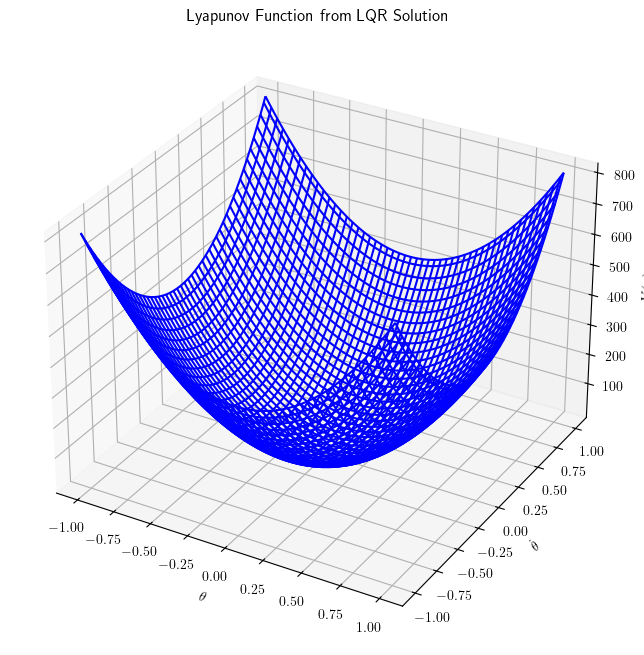

In [25]:
K_numpy, S = compute_lqr(A_numpy, B_numpy)
# convert to Tensors
K = torch.from_numpy(K_numpy).to(**set_t)  # linear feedback controller
S = torch.from_numpy(S).to(**set_t)  # quadratic Lyapunov function
print(f"K shape: {K.shape}")

# plot the output of the Lyapunov function for these samples
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
x_np = np.linspace(-1, 1, 100)
y_np = np.linspace(-1, 1, 100)
x_np, y_np = np.meshgrid(x_np, y_np)
lqr_lya = lambda x: np.sum(x * (x @ to_numpy(S)), axis=1)  # applies Lyapunov function to state inputs
x_orig = np.concatenate((x_np.ravel().reshape(-1, 1), y_np.ravel().reshape(-1, 1)), axis=1)
V_np = lqr_lya(np.concatenate((x_orig, np.zeros((x_orig.shape[0], A_numpy.shape[1] - 2))), axis=1))
V_np = V_np.reshape(x_np.shape)
ax.plot_wireframe(x_np, y_np, V_np, color='b')
ax.set_title("Lyapunov Function from LQR Solution")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\dot{\theta}$")
ax.set_zlabel(r"$V(x)$")
plt.show()

Feedback control should implement:
$$
\hat{x} := \text{ The equilibrium state, should be all 0s except position x, y, and z}
$$

$$
\bar{x} := x - \hat{x}
$$

$$
\hat{u} := u(\hat{x}), \text{ The equilibrium control input. In other words, the control fed to each propeller once the quadrotor is in its equilibrium state}
$$

$$
u(x) := \hat{u} - K\bar{x}
$$
States are represented as a 12 dimensional vector:
$$
x =
\begin{bmatrix}
\text{position x} \\
\text{position y} \\
\text{position z} \\
\text{roll} \\
\text{pitch} \\
\text{yaw} \\
\text{velocity x} \\
\text{velocity y} \\
\text{velocity z} \\
\text{angular velocity x} \\
\text{angular velocity y} \\
\text{angular velocity z} \\
\end{bmatrix}
$$

In [26]:
class LinearizedSystem:
    """
    This is a linear system w.r.t. A and B.

    States should be in order:
    [pos_x, pos_y, pos_z, phi, theta, psi, vel_x, vel_y, vel_z, p, q, r]
    Control inputs represent rotations per minute (rpm) for each motor.
    """
    def __init__(self, A: ndarray, B: ndarray, K: ndarray, controller: Callable,
                 eq_x: Optional[ndarray] = None, eq_u: Optional[ndarray] = None,
                 dt: float = 0.05, verbose: bool=False):
        """

        :param A:
        :param B:
        :param K:   Linear state-feedback controller.
        :param dt:  Discrete time step.
        """
        assert A.ndim == B.ndim == K.ndim == 2, "A and/or B is not two-dimensional."
        assert A.shape[0] == A.shape[1] == B.shape[0] == K.shape[1], "State dimension is not consistent among A, B, and K."
        assert B.shape[1] == K.shape[0], "B and K are not compatible."

        self._A = A
        self._B = B
        self._K = K
        self._nx = A.shape[0]
        self._nu = B.shape[1]
        self._nq = self._nx // 2
        self._dt = dt
        self._controller = controller
        if eq_x is not None:
            self._eq_x = eq_x
        else:
            self._eq_x = np.zeros(self._nx)
        # NOTE:
        #   eq_u (equilibrium_u) is not really relevant once we get the LQR controller, but if we
        #   have an idea of what it would look like at state equilibrium, this can help us
        #   get more accurate linearizations
        if eq_u is not None:
            self._eq_u = eq_u
        else:
            self._eq_u = np.zeros(self._nu)


        if verbose:
            print(f"A shape: {A.shape}")
            print(f"B shape: {B.shape}")
            print(f"K shape: {K.shape}")
            print(f"nx: {self._nx}")
            print(f"nu: {self._nu}")
            print(f"nq: {self._nq}")

    def forward(self, x: ndarray) -> Tuple[ndarray, ndarray]:
        assert x.ndim == 1, "x is not a vector."
        assert x.shape[0] == self._nx, "x is not the correct length."
        x_bar = (x - self._eq_x).reshape(-1, 1)
        # feedback_control = self._eq_u.reshape(-1, 1) + (-self._K @ x_bar)
        feedback_control = self._controller(x)
        xdot = self._A @ x_bar + self._B @ feedback_control
        # xdot = (self._A - self._B@self._K) @ x_bar
        xdot = xdot.flatten()

        # q = x[:self._nq]  # position/orientation states
        qdot = x[self._nq:]  # velocities
        qddot = xdot[self._nq:]  # accelerations

        x_new = x + self._dt * np.concatenate([qdot, qddot])

        return x_new, feedback_control.flatten()

    def __call__(self, x: ndarray) -> Tuple[ndarray, ndarray]:
        return self.forward(x)

    @property
    def equilibrium_x(self)->ndarray:
        return self._eq_x
    @property
    def equilibrium_u(self)->ndarray:
        return self._eq_u
    @property
    def nx(self) -> int:
        return self._nx
    @property
    def nu(self) -> int:
        return self._nu
    @property
    def nq(self) -> int:
        return self._nq

    @equilibrium_x.setter
    def equilibrium_x(self, value) -> None:
        self._eq_x = value
    @equilibrium_u.setter
    def equilibrium_u(self, value) -> None:
        self._eq_u = value

class NonlinearSystem:
    def __init__(self, A: ndarray, B: ndarray, K: ndarray, kf: float, km: float, m: float, g: float,
                 J1: float, J2: float, J3: float, L: float, controller: Callable,
                 eq_x: Optional[ndarray] = None, eq_u: Optional[ndarray] = None,
                 dt: float = 0.05,  verbose: bool=False):
        """

        :param A:
        :param B:
        :param K:   Linear state-feedback controller.
        :param dt:  Discrete time step.
        """
        assert A.ndim == B.ndim == K.ndim == 2, "A and/or B is not two-dimensional."
        assert A.shape[0] == A.shape[1] == B.shape[0] == K.shape[1], "State dimension is not consistent among A, B, and K."
        assert B.shape[1] == K.shape[0], "B and K are not compatible."

        self._A = A
        self._B = B
        self._K = K
        self._nx = A.shape[0]
        self._nu = B.shape[1]
        self._nq = self._nx // 2
        self._dt = dt
        self._controller = controller
        if eq_x is not None:
            self._eq_x = eq_x
        else:
            self._eq_x = np.zeros(self._nx)

        if eq_u is not None:
            self._eq_u = eq_u
        else:
            self._eq_u = np.zeros(self._nu)

        # save non-linear parameters
        self._kf = kf
        self._km = km
        self._m = m
        self._g = g
        self._L = L
        self._I = np.diag(np.array([J1, J2, J3]))
        self._I_inv = np.linalg.inv(self._I)

        if verbose:
            print(f"A shape: {A.shape}")
            print(f"B shape: {B.shape}")
            print(f"K shape: {K.shape}")
            print(f"nx: {self._nx}")
            print(f"nu: {self._nu}")
            print(f"nq: {self._nq}")
        pass

    @staticmethod
    def compute_rotation_matrix(phi: float, theta: float, psi: float) -> ndarray:
        return np.array([[np.cos(psi)*np.cos(theta) - np.sin(phi)*np.sin(psi)*np.sin(theta), -np.cos(phi)*np.sin(psi), np.cos(psi)*np.sin(theta) + np.cos(theta)*np.sin(phi)*np.sin(psi)],
                 [np.cos(theta)*np.sin(psi) + np.cos(psi)*np.sin(phi)*np.sin(theta), np.cos(phi)*np.cos(psi), np.sin(psi)*np.sin(theta) - np.cos(psi)*np.cos(theta)*np.sin(phi)],
                 [-np.cos(phi)*np.sin(theta), np.sin(phi), np.cos(phi)*np.cos(theta)]])

    def forward(self, x: ndarray) -> Tuple[ndarray, ndarray]:
        assert x.ndim == 1, "x is not a vector."
        assert x.shape[0] == self._nx, "x is not the correct length."

        # Get the feedback control obtained via LQR.
        # For a nonlinear system, we will now need to add
        # the control equilibrium.
        x_bar = (x - self._eq_x).reshape(-1, 1)
        u = self._eq_u.reshape(-1, 1) + (-self._K @ x_bar)  # rpm per rotor
        # u = self._controller(x)

        F = u**2 * self._kf  # force
        M = u**2 * self._km  # moment
        F1, F2, F3, F4 = F.flatten()
        M1, M2, M3, M4 = M.flatten()

        # unpack current states
        p1, p2, p3, phi, theta, psi, v1, v2, v3, p, q, r = x

        # calculate acceleration matrix
        R = NonlinearSystem.compute_rotation_matrix(phi, theta, psi)
        acc_matrix = (1/self._m) * (np.array([[0], [0], [-self._m*self._g]]) + R@np.array([[0], [0], [F.sum()]]))
        acc_matrix = acc_matrix.flatten()

        # calculate angular acceleration matrix
        ang_matrix = self._I_inv @ ( np.array([[self._L*(F2-F4)], [self._L*(F3-F1)], [M1 - M2 + M3 - M4]]) - ( np.array([[0, p, q], [-p , 0, r], [-q, -r, 0]])@( self._I@np.array([[p], [q], [r]]) ) ) )
        ang_matrix = ang_matrix.flatten()

        xdot = np.concatenate((x[self._nq:], acc_matrix, ang_matrix))

        # q = x[:self._nq]  # position/orientation states
        qdot = x[self._nq:]  # velocities
        qddot = xdot[self._nq:]  # accelerations

        x_new = x + self._dt * np.concatenate([qdot, qddot])

        return x_new, u.flatten()

    def __call__(self, x: ndarray) -> Tuple[ndarray, ndarray]:
        return self.forward(x)

    @property
    def equilibrium_x(self)->ndarray:
        return self._eq_x
    @property
    def equilibrium_u(self)->ndarray:
        return self._eq_u
    @property
    def nx(self) -> int:
        return self._nx
    @property
    def nu(self) -> int:
        return self._nu
    @property
    def nq(self) -> int:
        return self._nq

    @equilibrium_x.setter
    def equilibrium_x(self, value) -> None:
        self._eq_x = value
    @equilibrium_u.setter
    def equilibrium_u(self, value) -> None:
        self._eq_u = value

In [27]:
def initialize_system(delta_t: float, t_final: float, std: Optional[ndarray] = None, use_eq_u:bool = False, nonlinear:bool=False, controller: Optional[Callable] = None):

    # Define Simulation Parameters
    num_steps = int(t_final / delta_t)
    print(f"num_steps: {num_steps}")
    # since np.arange does not include t_final, we append it
    times = np.concatenate((np.arange(0, t_final, delta_t), np.array([t_final])))
    print(f"Number of simulation epochs: {len(times)}")

    # Define initial position & velocity
    mean = np.zeros(12)
    if std is None:
        std = np.zeros(12)
        std[:3] = 0.5  # std on position
        std[3:6] = 0.01  # std on orientation
        std[6:9] = 0.5  # std on velocity
        std[9:] = 0.05  # std on angular velocity
    noise = np.random.normal(loc=mean, scale=std, size=12)
    s_v = {str(k): v for k, v in values.items()}
    eq_x = np.array([s_v['px'], s_v['py'], s_v['pz'], s_v['phi'], s_v['theta'], s_v['psi'],
              s_v['vx'], s_v['vy'], s_v['vz'], s_v['p'], s_v['q'], s_v['r']])
    eq_u = np.array([s_v['u1'], s_v['u2'], s_v['u3'], s_v['u4']]) if use_eq_u else None
    init_x = eq_x + noise

    # Initialize the dynamical system to use
    # dynamical_system = LinearizedSystem(A_reordered, B_reordered, K_reordered, delta_t, verbose=True)
    Q_weights = np.ones((A_numpy.shape[1]))
    Q_weights[:3] *= 400
    # Q_weights[3:6] *= 40
    # Q_weights[6:9] *= 40
    # Q_weights[9:12] *= 80
    R_weights = np.ones((B_numpy.shape[1]))
    K_numpy, S = compute_lqr(A_numpy, B_numpy, Q_weights=Q_weights, R_weights=R_weights)
    print(f"K_numpy: {K_numpy}")


    # x_bar = (x - self._eq_x).reshape(-1, 1)
        # u = self._eq_u.reshape(-1, 1) + (-self._K @ x_bar)  # rpm per rotor

    if controller is None:
        def controller(x: ndarray) -> ndarray:
            x_bar = (x - eq_x).reshape(-1, 1)
            eq_u = np.array([s_v['u1'], s_v['u2'], s_v['u3'], s_v['u4']]).reshape(-1, 1)
            u = eq_u - K_numpy @ x_bar
            return u

    init_system_args = {'A': A_numpy, 'B': B_numpy, 'K': K_numpy, 'eq_x': eq_x, 'eq_u': eq_u, 'dt': delta_t,
                        'controller': controller, 'verbose': True}
    if nonlinear:
        nonlinear_args = {'kf': s_v['kf'], 'km': s_v['km'], 'm': s_v['m'], 'g': s_v['g'], 'L': s_v['L'], 'J1': s_v['I1'], 'J2': s_v['I2'], 'J3': s_v['I3']}
        init_system_args.update(nonlinear_args)
        dynamical_system = NonlinearSystem(**init_system_args)
    else:
        dynamical_system = LinearizedSystem(**init_system_args)

    return times, init_x, dynamical_system

# Function to get the vertices of the quadrotor (box)
def get_box_vertices(center, orientation, box_dimensions):
    """

    :param center:          (x, y, z) position of the center of the
                            quadrotor in the world frame
    :param orientation:     (ϕ, θ, ψ), a.k.a. the roll, pitch, and yaw
                            of the quadrotor
    :param box_dimensions:  (L, W, H), the length, width, and height
                            of the simplified quadrotor box.
    :return:
    """

    roll, pitch, yaw = orientation
    L, W, H = box_dimensions
    rot_m = NonlinearSystem.compute_rotation_matrix(roll, pitch, yaw)
    orig_vertices = np.array([
        [0-L/2, 0-W/2, 0-H/2], [0+L/2, 0-W/2, 0-H/2],
        [0+L/2, 0+W/2, 0-H/2], [0-L/2, 0+W/2, 0-H/2],
        [0-L/2, 0-W/2, 0+H/2], [0+L/2, 0-W/2, 0+H/2],
        [0+L/2, 0+W/2, 0+H/2], [0-L/2, 0+W/2, 0+H/2]
    ])
    rot_vertices = np.einsum('ij,bj->bi', rot_m, orig_vertices)
    rot_offset_vertices = rot_vertices + center.reshape(1, -1)
    return rot_offset_vertices

def run_system(system, init_x: ndarray, num_epochs: int) -> Tuple[ndarray, ndarray]:
    """

    :param system:
    :param init_x:
    :param num_epochs:
    :return:
    """
    state_history = np.zeros((num_epochs, system.nx))
    control_history = np.zeros((num_epochs, system.nu))
    state_history[0, :] = init_x
    curr_x = init_x
    for i in range(1, num_epochs):
        new_x, new_u = system(curr_x)
        state_history[i, :] = new_x
        control_history[i-1, :] = new_u
        curr_x = new_x

    return state_history, control_history

def initialize_plot(init_x, dynamical_system, LWH: Tuple[int, int, int], figsize: Tuple[int, int] = (16, 12),
                    ax1_upper_limits: Optional[ndarray] = None,
                    ax1_lower_limits: Optional[ndarray] = None,):
    L, W, H = LWH
    init_position = init_x[:3]
    init_orientation = init_x[3:6]
    # Create figure and 3D axis
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(5, 4, figure=fig)
    ax1 = fig.add_subplot(gs[:2, :2], projection='3d')
    axs = []
    pos_mask = np.ones((5,4), dtype=bool)
    pos_mask[:2, :2] = False
    positions = np.argwhere(pos_mask)
    for row, col in positions:
        ax = fig.add_subplot(gs[row, col])
        axs.append(ax)
    time_marker = [ax.axvline(x=0, color='k', linestyle="--", lw=1.5) for ax in axs]
    if ax1_upper_limits is not None and ax1_lower_limits is not None:
        ax1.set_xlim(ax1_lower_limits[0]-1, ax1_upper_limits[0]+1)
        ax1.set_ylim(ax1_lower_limits[1]-1, ax1_upper_limits[1]+1)
        ax1.set_zlim(ax1_lower_limits[2]-1, ax1_upper_limits[2]+1)
    else:
        # assume a small region near initial position is good enough
        ax1.set_xlim(init_position[0]-1, init_position[0]+1)
        ax1.set_ylim(init_position[1]-1, init_position[1]+1)
        ax1.set_zlim(init_position[2]-1, init_position[2]+1)

    # Initialize quadrotor box
    vertices = get_box_vertices(init_position, np.zeros(3), (L, W, H))
    faces = [[vertices[j] for j in [0,1,2,3]], [vertices[j] for j in [4,5,6,7]],
             [vertices[j] for j in [0,1,5,4]], [vertices[j] for j in [2,3,7,6]],
             [vertices[j] for j in [0,3,7,4]], [vertices[j] for j in [1,2,6,5]]]
    quadrotor = Poly3DCollection(faces, alpha=0.5, color='blue', label='Quadrotor')
    ax1.add_collection3d(quadrotor)

    # Display the positional equilirbium point
    static_point = dynamical_system.equilibrium_x[:3]
    static_orientation = dynamical_system.equilibrium_x[3:6]
    ax1.scatter(*static_point, color="red", label="Equilibrium", s=25)

    # Define edges of the box of the quadrotor when it is at equilibrium
    eq_vertices = get_box_vertices(static_point, static_orientation, (L, W, H))
    edges = [
        [eq_vertices[j] for j in [0, 1]], [eq_vertices[j] for j in [1, 2]],
        [eq_vertices[j] for j in [2, 3]], [eq_vertices[j] for j in [3, 0]],
        [eq_vertices[j] for j in [4, 5]], [eq_vertices[j] for j in [5, 6]],
        [eq_vertices[j] for j in [6, 7]], [eq_vertices[j] for j in [7, 4]],
        [eq_vertices[j] for j in [0, 4]], [eq_vertices[j] for j in [1, 5]],
        [eq_vertices[j] for j in [2, 6]], [eq_vertices[j] for j in [3, 7]],
    ]

    # Create a dashed outline for the equilibrium box
    equilibrium_outline = Line3DCollection(edges, colors='red', linewidths=1.5, linestyles="dashed")
    ax1.add_collection3d(equilibrium_outline)

    return fig, ax1, axs, time_marker, quadrotor

def plot_last_frame(fig, ax1, axs, quadrotor, dynamical_system, times, state_history, control_history,
                    labels, colors):
    eq_x = dynamical_system.equilibrium_x
    eq_u = dynamical_system.equilibrium_u
    position = state_history[-1, :3]
    orientation = state_history[-1, 3:6]
    vertices = get_box_vertices(position, orientation, (L, W, H))
    faces = [[vertices[j] for j in [0,1,2,3]], [vertices[j] for j in [4,5,6,7]],
             [vertices[j] for j in [0,1,5,4]], [vertices[j] for j in [2,3,7,6]],
             [vertices[j] for j in [0,3,7,4]], [vertices[j] for j in [1,2,6,5]]]
    quadrotor.set_verts(faces)
    max_states = state_history.max(axis=0)
    min_states = state_history.min(axis=0)
    max_controls = control_history.max(axis=0)
    min_controls = eq_u - np.abs(eq_u - max_controls)
    for i, ax in enumerate(axs):
        ax.clear()  # Clear old plot
        ax.set_xlim(0, t_final)
        if i < 12:
            # these are subplots for the state trajectory
            ax.set_ylim(min_states[i], max_states[i])
            ax.plot(times, state_history[:, i], color=colors[i], label=labels[i])
            ax.axhline(eq_x[i], color=colors[i], linestyle="dashed", label="Equilibrium")
        else:
            # these are subplots for the control history
            ax.set_ylim(min_controls[i - 12], max_controls[i - 12])
            # ax.set_ylim(eq_u[i-12] - 1000, eq_u[i-12] + 1000)
            ax.plot(times, control_history[:, i - 12], color=colors[i], label=labels[i])
            ax.axhline(eq_u[i - 12], color=colors[i], linestyle="dashed", label="Equilibrium")
        ax.set_ylabel(labels[i])
        ax.legend()
        ax.grid()

def produce_animation(fig, ax1, axs, delta_t: float, t_final: float, LWH: Tuple[int, int, int],
                      dynamical_system, quadrotor,
                      state_history: ndarray, control_history: ndarray, time_marker,
                      colors, labels: List[str], use_5_fps=False):

    eq_x = dynamical_system.equilibrium_x
    eq_u = dynamical_system.equilibrium_u
    L, W, H = LWH
    max_states = state_history.max(axis=0)
    min_states = state_history.min(axis=0)
    max_controls = control_history.max(axis=0)
    min_controls = eq_u - np.abs(eq_u - max_controls)
    if use_5_fps:
        o = int(1 / (5*delta_t))  # number of frames to skip to achieve 5 fps
        num_steps = int(t_final * 5)
    else:
        o = 1
        num_steps = int(t_final / delta_t)

    epoch_progress_bar = tqdm(range(num_steps + 1), desc="Frames Processed", leave=True)
    def _update(frame: int) -> Poly3DCollection:
        """

        :param frame: Current frame index
        :return:
        """
        t = frame * o
        curr_state = state_history[t, :]
        position = curr_state[:3]
        orientation = curr_state[3:6]
        vertices = get_box_vertices(position, orientation, (L, W, H))
        faces = [[vertices[j] for j in [0,1,2,3]], [vertices[j] for j in [4,5,6,7]],
                 [vertices[j] for j in [0,1,5,4]], [vertices[j] for j in [2,3,7,6]],
                 [vertices[j] for j in [0,3,7,4]], [vertices[j] for j in [1,2,6,5]]]
        quadrotor.set_verts(faces)

        for i, ax in enumerate(axs):
            ax.clear()  # Clear old plot
            ax.set_xlim(0, t_final)
            if i < 12:
                # these are subplots for the state trajectory
                ax.set_ylim(min_states[i], max_states[i])
                ax.plot(times[:t], state_history[:t, i], color=colors[i], label=labels[i])
                ax.axhline(eq_x[i], color=colors[i], linestyle="dashed", label="Equilibrium")
            else:
                # these are subplots for the control history
                ax.set_ylim(min_controls[i - 12], max_controls[i - 12])
                ax.plot(times[:t], control_history[:t, i - 12], color=colors[i], label=labels[i])
                ax.axhline(eq_u[i - 12], color=colors[i], linestyle="dashed", label="Equilibrium")
            ax.set_ylabel(labels[i])
            ax.legend()
            ax.grid()

            # Update time marker
            time_marker[i].set_xdata([times[t]])

        epoch_progress_bar.update(1)

        return quadrotor

    # Create animation
    ani = animation.FuncAnimation(fig, _update, frames=num_steps, interval=delta_t * 1000, blit=False)

    # Add a legend
    ax1.legend()

    return ani

# LQR for a Linearized Quadrotor

This cell linearizes the quadrotor about an equilibrium point and produces an LQR state-feedback controller for this linearized system. For simulation, we stick to the linear system which is stabilizable *everywhere*. However, this linear system violates the true nonlinear dynamics of the quadrotor as this linearized system is only accurate near the equilibrium point.

num_steps: 2400
Number of simulation epochs: 2401
K_numpy: [[-1.41421356e+01  7.34496958e-16  1.00000000e+01 -3.53620665e-14
  -2.31046637e+02  5.00000000e-01 -2.58196727e+01  2.47304013e-15
   1.21476031e+02 -3.66468776e-15 -1.23436488e+02  5.95220734e+00]
 [-8.28523376e-15 -1.41421356e+01  1.00000000e+01  2.31046637e+02
  -3.93725253e-14 -5.00000000e-01 -7.09950563e-15 -2.58196727e+01
   1.21476031e+02  1.23436488e+02 -1.04001312e-14 -5.95220734e+00]
 [ 1.41421356e+01  9.85655969e-15  1.00000000e+01 -6.15560052e-14
   2.31046637e+02  5.00000000e-01  2.58196727e+01  1.19748458e-14
   1.21476031e+02 -2.38349443e-14  1.23436488e+02  5.95220734e+00]
 [ 7.86939219e-15  1.41421356e+01  1.00000000e+01 -2.31046637e+02
   2.93562459e-14 -5.00000000e-01  5.62202946e-15  2.58196727e+01
   1.21476031e+02 -1.23436488e+02  9.77012540e-15 -5.95220734e+00]]
A shape: (12, 12)
B shape: (12, 4)
K shape: (4, 12)
nx: 12
nu: 4
nq: 6
Initial state: 
[ 8.78647381e+00  9.82271617e+00  9.40820227e+00  1.77390

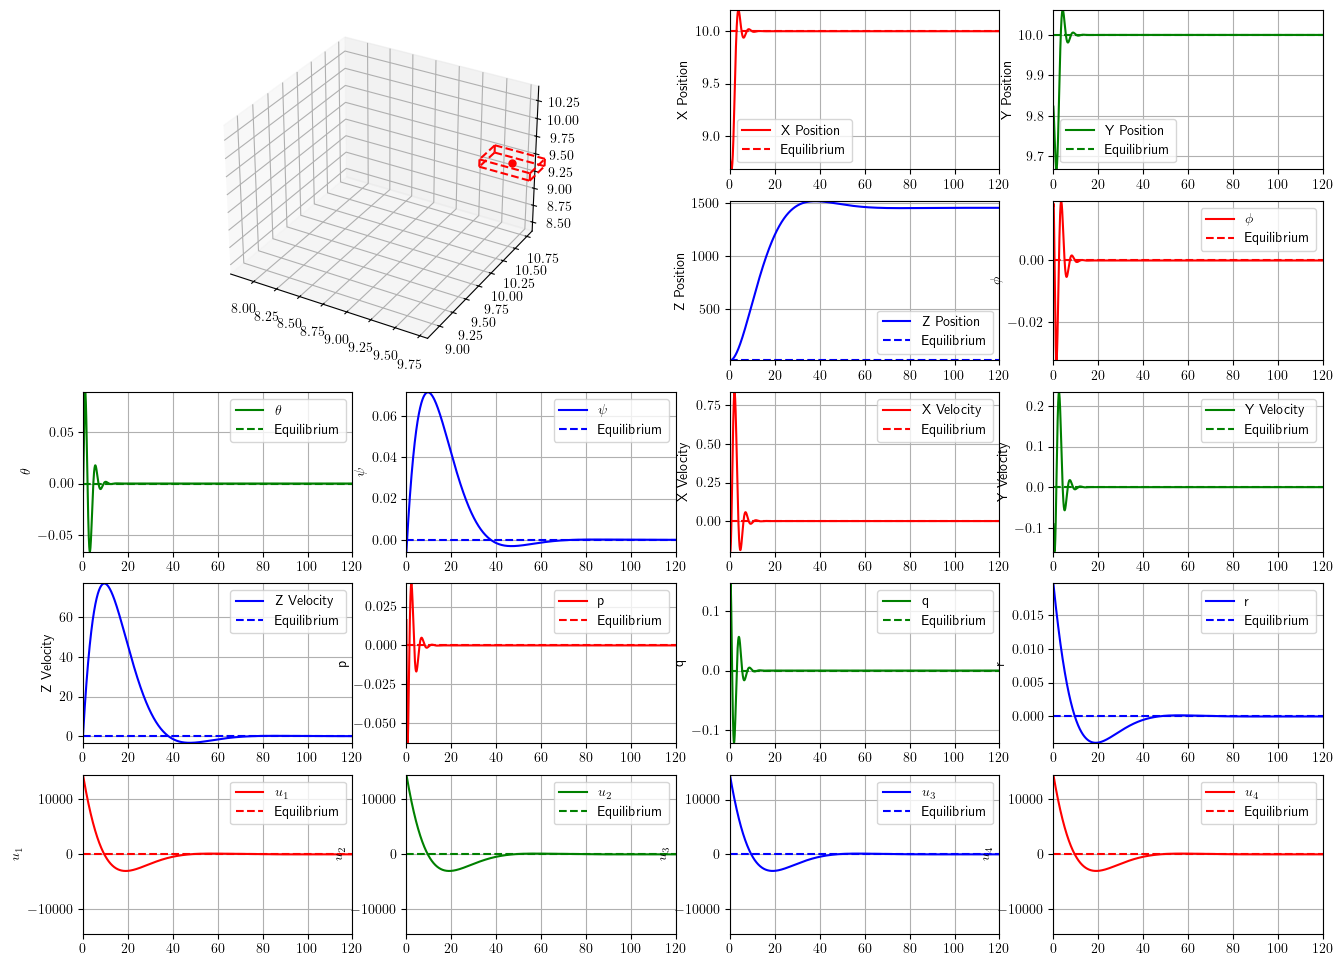

In [28]:
# Quadrotor Box Dimensions. The quadrotor is an abstract box in the visualization,
# but dynamical updates are w.r.t. our dynamical equations above.
L, W, H = 0.5, 0.3, 0.1  # Length, Width, Height of the box
# set up the simulation parameters
delta_t = 0.05   # Time step
t_final = 120.0    # Total simulation time (seconds)
labels = ['X Position', 'Y Position', 'Z Position', r'$\phi$', r'$\theta$', r'$\psi$', 'X Velocity', 'Y Velocity', 'Z Velocity', 'p', 'q', 'r', r'$u_1$', r'$u_2$', r'$u_3$', r'$u_4$']
colors = ['r', 'g', 'b'] * 7

# initialize the system
times, init_x, dynamical_system = initialize_system(delta_t, t_final)
print(f"Initial state: \n{init_x}")

# run the simulated trajectory
state_history, control_history = run_system(dynamical_system, init_x, len(times))

# initialize the matplotlib fig and axes
fig, ax1, axs, time_marker, quadrotor = initialize_plot(init_x, dynamical_system, (L, W, H))

# plot the last frame
plot_last_frame(fig, ax1, axs, quadrotor, dynamical_system, times, state_history, control_history,
                    labels, colors)

In [92]:
# NOTE: Can take ~10 min. to produce a video clip at 5 fps
# run the simulation
use_5_fps = True
fps = 5 if use_5_fps else int(1/delta_t)
start_sim = time()
ani_obj = produce_animation(fig, ax1, axs, delta_t, t_final, (L, W, H), dynamical_system, quadrotor,
                      state_history, control_history, time_marker,
                      colors, labels, use_5_fps=use_5_fps)
end_sim = time()
print(f"Took {end_sim - start_sim} seconds to conduct simulation.")
# save the simulation to .mp4
start_save = time()
metadata = {'title': 'My Animation', 'artist': 'Matplotlib'}
writer = FFMpegWriter(fps=fps, metadata=metadata, codec="libx264", extra_args=['-preset', 'fast', '-crf', '20', '-threads', '16'])
ani_obj.save("quadrotor_lqr_stabilization.mp4", writer=writer)
# ani_obj.save("quadrotor_lqr_stabilization.mp4", writer="ffmpeg", fps=int(1/delta_t))  # Save as video
end_save = time()
print(f"Took {end_save - start_save} seconds to save animation.")


Frames Processed:   0%|          | 2/601 [00:00<00:56, 10.61it/s]

Took 0.002254962921142578 seconds to conduct simulation.



Frames Processed:   4%|▍         | 27/601 [00:27<11:07,  1.16s/it]

CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1600x1200', '-pix_fmt', 'rgba', '-framerate', '5', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'libx264', '-metadata', 'title=My Animation', '-metadata', 'artist=Matplotlib', '-preset', 'fast', '-crf', '20', '-threads', '16', '-y', 'quadrotor_lqr_stabilization.mp4']' returned non-zero exit status 255.

# LQR for a Nonlinear Quadrotor

We still linearize the quadrotor about an equilibrium point in order to produce an LQR controller. However, when performing the simulation, we use the true non-linear dynamics and not the linearized system. The LQR controller is capable of stabilizing the quadrotor near the equilibrium point, but as the quadrotor deviates further from the equilibrium point, the system can no longer be stabilized.

num_steps: 2400
Number of simulation epochs: 2401
K_numpy: [[-1.41421356e+01  7.34496958e-16  1.00000000e+01 -3.53620665e-14
  -2.31046637e+02  5.00000000e-01 -2.58196727e+01  2.47304013e-15
   1.21476031e+02 -3.66468776e-15 -1.23436488e+02  5.95220734e+00]
 [-8.28523376e-15 -1.41421356e+01  1.00000000e+01  2.31046637e+02
  -3.93725253e-14 -5.00000000e-01 -7.09950563e-15 -2.58196727e+01
   1.21476031e+02  1.23436488e+02 -1.04001312e-14 -5.95220734e+00]
 [ 1.41421356e+01  9.85655969e-15  1.00000000e+01 -6.15560052e-14
   2.31046637e+02  5.00000000e-01  2.58196727e+01  1.19748458e-14
   1.21476031e+02 -2.38349443e-14  1.23436488e+02  5.95220734e+00]
 [ 7.86939219e-15  1.41421356e+01  1.00000000e+01 -2.31046637e+02
   2.93562459e-14 -5.00000000e-01  5.62202946e-15  2.58196727e+01
   1.21476031e+02 -1.23436488e+02  9.77012540e-15 -5.95220734e+00]]
A shape: (12, 12)
B shape: (12, 4)
K shape: (4, 12)
nx: 12
nu: 4
nq: 6
Initial state: 
[ 9.72569014e+00  6.17818509e+00  1.01500860e+01 -5.06741

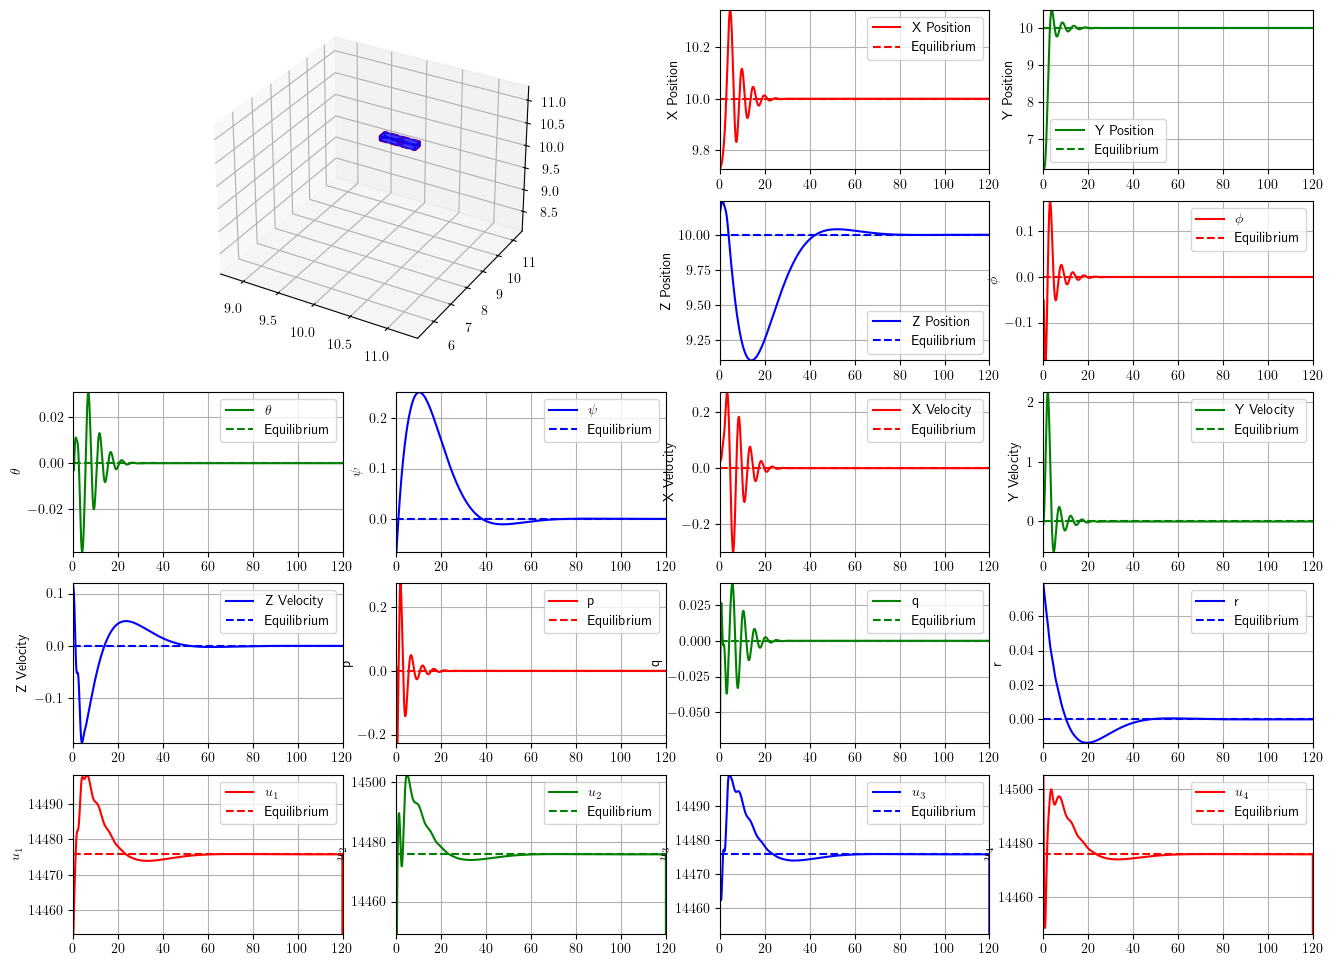

In [83]:
# Quadrotor Box Dimensions. The quadrotor is an abstract box in the visualization,
# but dynamical updates are w.r.t. our dynamical equations above.
L, W, H = 0.5, 0.3, 0.1  # Length, Width, Height of the box
# set up the simulation parameters
delta_t = 0.05   # Time step
t_final = 120.0    # Total simulation time (seconds)
labels = ['X Position', 'Y Position', 'Z Position', r'$\phi$', r'$\theta$', r'$\psi$', 'X Velocity', 'Y Velocity', 'Z Velocity', 'p', 'q', 'r', r'$u_1$', r'$u_2$', r'$u_3$', r'$u_4$']
colors = ['r', 'g', 'b'] * 7

# initialize the system
std = np.zeros(12)
std[:3] = 5.0  # std on position
std[3:6] = 0.1  # std on orientation
std[6:9] = 0.1  # std on velocity
std[9:] = 0.1  # std on angular velocity
times, init_x, dynamical_system = initialize_system(delta_t, t_final, std=std, use_eq_u=True, nonlinear=True)
print(f"Initial state: \n{init_x}")

# run the simulated trajectory
state_history, control_history = run_system(dynamical_system, init_x, len(times))

# initialize the matplotlib fig and axes
max_states = state_history.max(axis=0)
min_states = state_history.min(axis=0)
max_pos = to_numpy(max_states[:3])
min_pos = to_numpy(min_states[:3])
fig, ax1, axs, time_marker, quadrotor = initialize_plot(init_x, dynamical_system, (L, W, H), ax1_lower_limits=min_pos, ax1_upper_limits=max_pos)

# plot the last frame
plot_last_frame(fig, ax1, axs, quadrotor, dynamical_system, times, state_history, control_history,
                    labels, colors)

In [26]:
# NOTE: Can take ~10 min. to produce a video clip at 5 fps
# run the simulation
use_5_fps = True
fps = 5 if use_5_fps else int(1/delta_t)
start_sim = time()
ani_obj = produce_animation(fig, ax1, axs, delta_t, t_final, (L, W, H), dynamical_system, quadrotor,
                      state_history, control_history, time_marker,
                      colors, labels, use_5_fps=use_5_fps)
end_sim = time()
print(f"Took {end_sim - start_sim} seconds to conduct simulation.")
# save the simulation to .mp4
start_save = time()
metadata = {'title': 'My Animation', 'artist': 'Matplotlib'}
writer = FFMpegWriter(fps=fps, metadata=metadata, codec="libx264", extra_args=['-preset', 'fast', '-crf', '20', '-threads', '16'])
ani_obj.save("nonlinear_quadrotor_lqr_stabilization.mp4", writer=writer)
# ani_obj.save("quadrotor_lqr_stabilization.mp4", writer="ffmpeg", fps=int(1/delta_t))  # Save as video
end_save = time()
print(f"Took {end_save - start_save} seconds to save animation.")

Frames Processed:   0%|          | 1/601 [00:00<01:04,  9.37it/s]

Took 0.013395071029663086 seconds to conduct simulation.


Frames Processed: 100%|██████████| 601/601 [10:40<00:00,  1.13s/it]

Took 641.4189553260803 seconds to save animation.


In [57]:
pth_path = "/home/jorgejc2/Documents/ClassRepos/ISS_Lyapunov_Stable_NN_Controllers/output/quadrotor_state_training/2025-03-25/22-52-24/lyaloss_1.0.pth"
import neural_lyapunov_training.controllers as controllers
import neural_lyapunov_training.dynamical_system as dynamical_system
import neural_lyapunov_training.lyapunov as lyapunov
from new_quadrotor_dynamics import QuadrotorDynamics
quadrotor_tracking_continous = QuadrotorDynamics()
temp_dynamics = dynamical_system.SecondOrderDiscreteTimeSystem(
    quadrotor_tracking_continous,
    dt=0.05
)
controller_nn = controllers.NeuralNetworkController(
        nlayer=5,
        in_dim=quadrotor_tracking_continous.nx,
        out_dim=quadrotor_tracking_continous.nu,
        hidden_dim=64,
        clip_output="clamp",
        u_lo=torch.tensor([0.]*4),
        u_up=torch.tensor([18000]*4),  # reported upper limit of crazyflie 2.0 drone
        x_equilibrium=quadrotor_tracking_continous.x_equilibrium,
        u_equilibrium=quadrotor_tracking_continous.u_equilibrium,
    )
lyapunov_nn = lyapunov.NeuralNetworkQuadraticLyapunov(
            goal_state=quadrotor_tracking_continous.x_equilibrium,
            x_dim=quadrotor_tracking_continous.nx,
            R_rows=quadrotor_tracking_continous.nx,
            eps=0.01,
        )
derivative_lyaloss = lyapunov.LyapunovDerivativeLoss(
                temp_dynamics,
                controller_nn,
                lyapunov_nn,
                box_lo=torch.zeros(12),
                box_up=torch.zeros(12),
                rho_multiplier=1,
                kappa=0.1,
                hard_max=1
            )
pth_dict = torch.load(pth_path)
derivative_lyaloss.load_state_dict(pth_dict['state_dict'])
controller_nn = derivative_lyaloss.controller
def controller(x: ndarray) -> ndarray:
    x_t = torch.from_numpy(x).unsqueeze(0).to(dtype=torch.float)
    u_t = controller_nn(x_t)
    u = to_numpy(u_t.squeeze(0))
    return u

Currently the controller is poorly trained and causes the system to diverge.

num_steps: 2400
Number of simulation epochs: 2401
K_numpy: [[-1.41421356e+01  7.34496958e-16  1.00000000e+01 -3.53620665e-14
  -2.31046637e+02  5.00000000e-01 -2.58196727e+01  2.47304013e-15
   1.21476031e+02 -3.66468776e-15 -1.23436488e+02  5.95220734e+00]
 [-8.28523376e-15 -1.41421356e+01  1.00000000e+01  2.31046637e+02
  -3.93725253e-14 -5.00000000e-01 -7.09950563e-15 -2.58196727e+01
   1.21476031e+02  1.23436488e+02 -1.04001312e-14 -5.95220734e+00]
 [ 1.41421356e+01  9.85655969e-15  1.00000000e+01 -6.15560052e-14
   2.31046637e+02  5.00000000e-01  2.58196727e+01  1.19748458e-14
   1.21476031e+02 -2.38349443e-14  1.23436488e+02  5.95220734e+00]
 [ 7.86939219e-15  1.41421356e+01  1.00000000e+01 -2.31046637e+02
   2.93562459e-14 -5.00000000e-01  5.62202946e-15  2.58196727e+01
   1.21476031e+02 -1.23436488e+02  9.77012540e-15 -5.95220734e+00]]
A shape: (12, 12)
B shape: (12, 4)
K shape: (4, 12)
nx: 12
nu: 4
nq: 6
Initial state: 
[ 9.72569014e+00  6.17818509e+00  1.01500860e+01 -5.06741

ValueError: Axis limits cannot be NaN or Inf

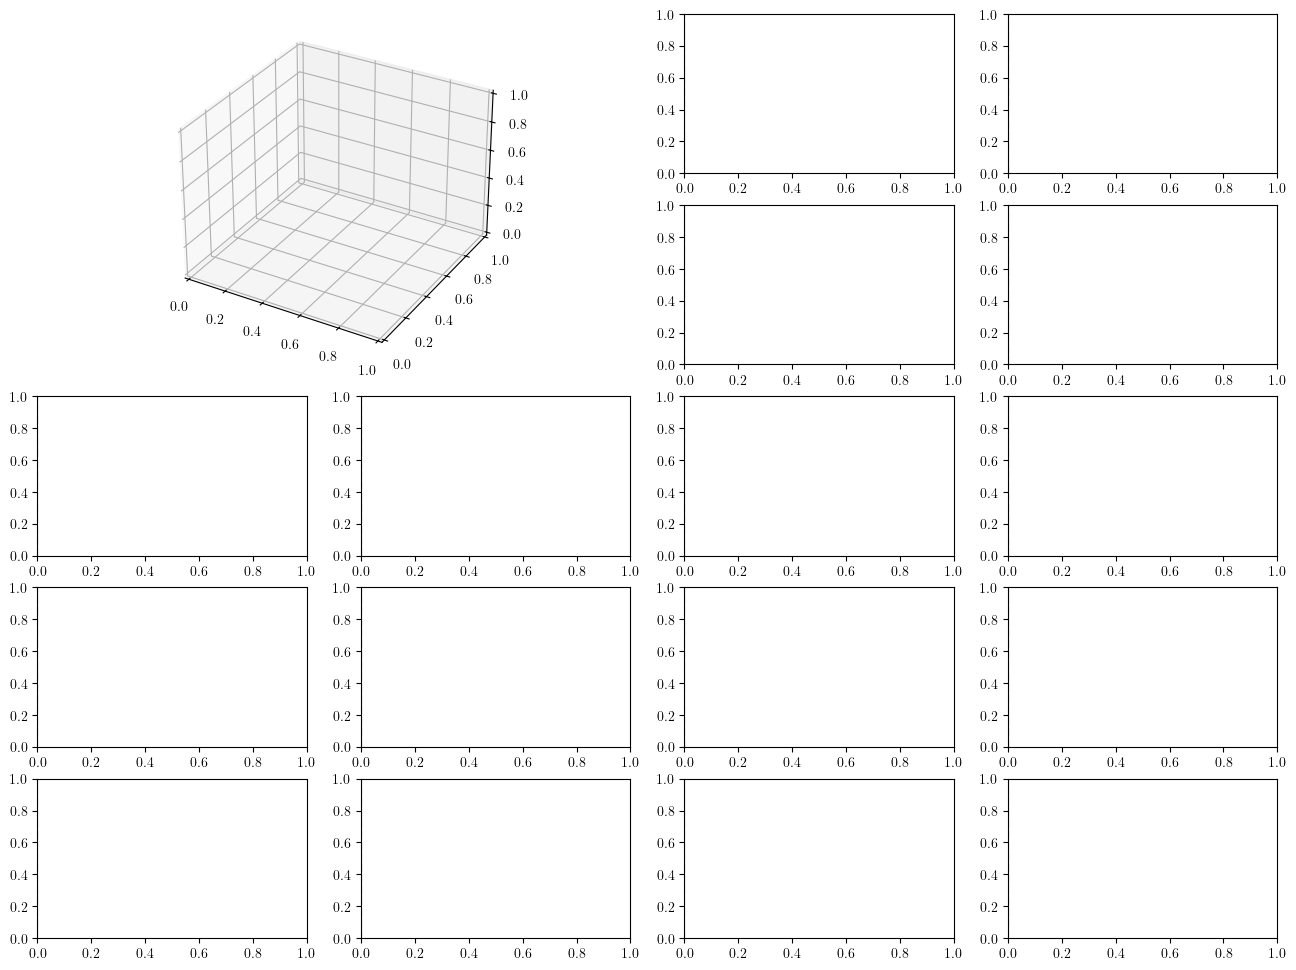

In [84]:
# Quadrotor Box Dimensions. The quadrotor is an abstract box in the visualization,
# but dynamical updates are w.r.t. our dynamical equations above.
L, W, H = 0.5, 0.3, 0.1  # Length, Width, Height of the box
# set up the simulation parameters
delta_t = 0.05   # Time step
t_final = 120.0    # Total simulation time (seconds)
labels = ['X Position', 'Y Position', 'Z Position', r'$\phi$', r'$\theta$', r'$\psi$', 'X Velocity', 'Y Velocity', 'Z Velocity', 'p', 'q', 'r', r'$u_1$', r'$u_2$', r'$u_3$', r'$u_4$']
colors = ['r', 'g', 'b'] * 7

# initialize the system
std = np.zeros(12)
std[:3] = 5.0  # std on position
std[3:6] = 0.1  # std on orientation
std[6:9] = 0.1  # std on velocity
std[9:] = 0.1 # std on angular velocity
times, _, dynamical_system = initialize_system(delta_t, t_final, std=std, use_eq_u=True, nonlinear=True,
                                                    controller=controller)
# We use the same init_x as the one used for the non-linaer system with the LQR controller
print(f"Initial state: \n{init_x}")

# run the simulated trajectory
state_history, control_history = run_system(dynamical_system, init_x, len(times))

# initialize the matplotlib fig and axes
max_states = state_history.max(axis=0)
min_states = state_history.min(axis=0)
max_pos = to_numpy(max_states[:3])
min_pos = to_numpy(min_states[:3])
fig, ax1, axs, time_marker, quadrotor = initialize_plot(init_x, dynamical_system, (L, W, H), ax1_lower_limits=min_pos, ax1_upper_limits=max_pos)

# plot the last frame
plot_last_frame(fig, ax1, axs, quadrotor, dynamical_system, times, state_history, control_history,
                    labels, colors)